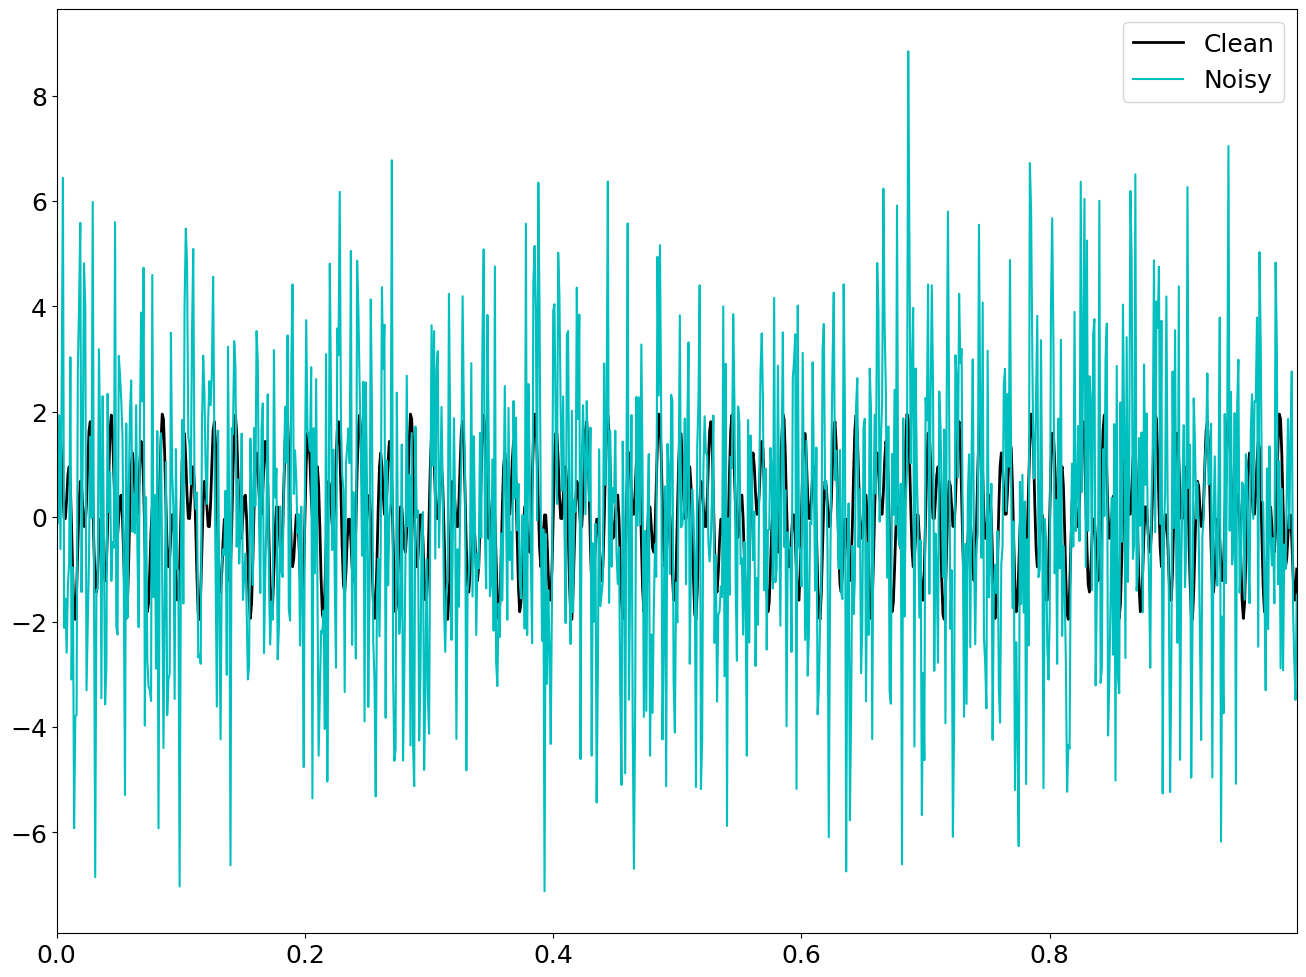

In [11]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [16, 12]
plt.rcParams.update({'font.size': 18})

# Create a simple signal with two frequencies
dt = 0.001
t = np.arange(0,1,dt)
f = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t) # sum of 2 frequencies
f_clean = f.copy()
f = f + 2.5*np.random.randn(len(t)) # add some noise

plt.plot(t, f_clean, color='k', linewidth=2, label='Clean')
plt.plot(t, f, color='c', linewidth=1.5, label='Noisy')
plt.xlim(t[0],t[-1])
plt.legend()

/Users/tomasgutierrez/projects/DURF/venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/tomasgutierrez/projects/DURF/venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


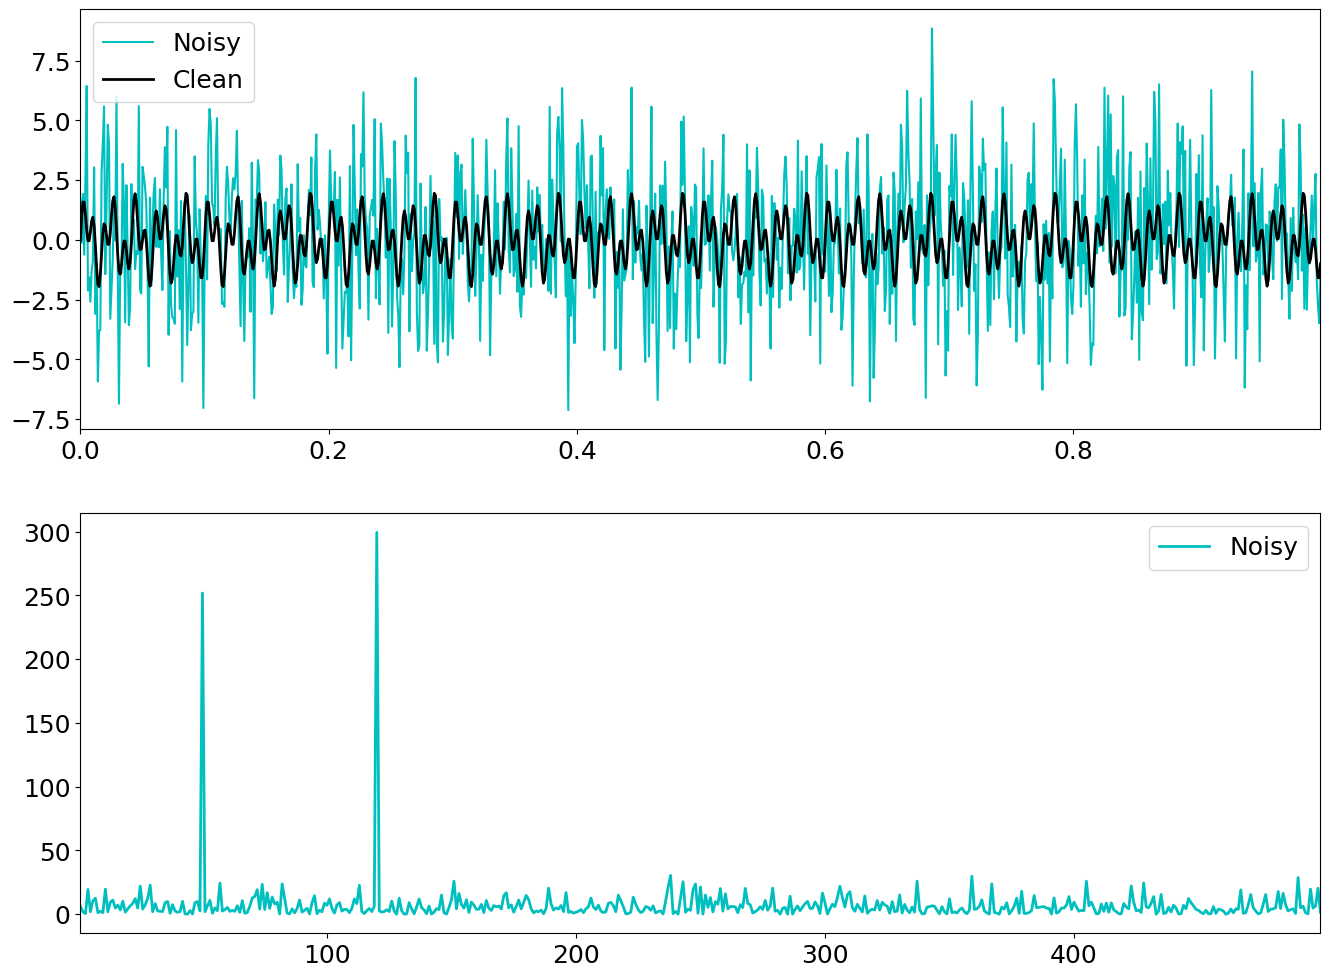

In [15]:
## Compute Fast Fourier Transform (FFT)

n = len(t)
fhat = np.fft.fft(f, n) # Compute the FFT
PSD = fhat * np.conj(fhat) / n # Power Spectrum
freq = (1/(dt*n)) * np.arange(n) # Create x-axis of frequencies
L = np.arange(1,np.floor(n/2),dtype='int') # Only plot the first half

fig, axs = plt.subplots(2,1)

plt.sca(axs[0])
plt.plot(t,f,color='c', linewidth=1.5, label='Noisy')
plt.plot(t,f_clean,color='k', linewidth=2, label='Clean')
plt.xlim(t[0],t[-1])
plt.legend()

plt.sca(axs[1])
plt.plot(freq[L],PSD[L],color='c',linewidth=2,label='Noisy')
plt.xlim(freq[L[0]],freq[L[-1]])
plt.legend()

plt.show()

In [ ]:
indices = PSD > 100
PSDclean = PSD * indices
fhat = indices * fhat
ffilt = np.fft.ifft(fhat)

/Users/tomasgutierrez/projects/DURF/venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/tomasgutierrez/projects/DURF/venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


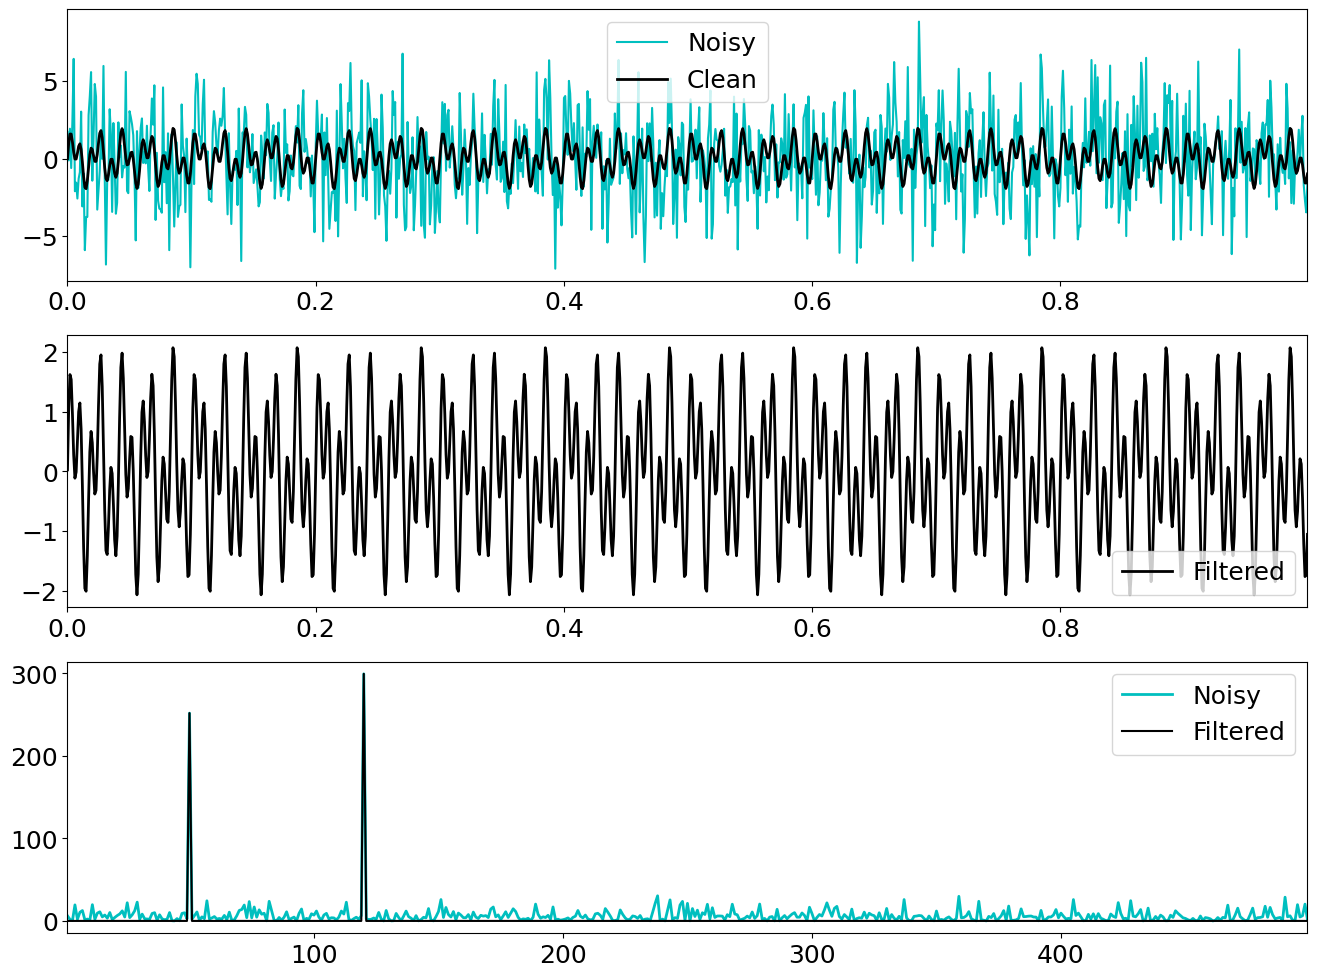

In [16]:

fig,axs = plt.subplots(3,1)

plt.sca(axs[0])
plt.plot(t,f,color='c', linewidth=1.5, label='Noisy')
plt.plot(t,f_clean,color='k', linewidth=2, label='Clean')
plt.xlim(t[0],t[-1])
plt.legend()

plt.sca(axs[1])
plt.plot(t,ffilt,color='k', linewidth=2, label='Filtered')
plt.xlim(t[0],t[-1])
plt.legend()

plt.sca(axs[2])
plt.plot(freq[L],PSD[L],color='c',linewidth=2,label='Noisy')
plt.plot(freq[L],PSDclean[L],color='k',linewidth=1.5,label='Filtered')
plt.xlim(freq[L[0]],freq[L[-1]])
plt.legend()

plt.show()